# Vector Space Models: TF-IDF vs LSI vs Transformer Embeddings

In the **Vector Space Model (VSM)**, every document and query is represented as a vector in a high-dimensional space. Relevance = geometric closeness (cosine similarity).

This notebook compares three ways to build those vectors, from simplest to most powerful:

| # | Model | Representation |
|---|-------|----------------|
| 1 | **Normal VSM** | Sparse TF-IDF vectors (vocabulary-size dimensions) |
| 2 | **VSM + LSI** | TF-IDF compressed to 300 latent topics via SVD |
| 3 | **VSM + Transformers** | 384-dim dense embeddings from `all-MiniLM-L6-v2` |

The key question: does richer representation pay off?

| Step | What we do |
|------|------------|
| 1 | Load the dataset |
| 2 | Visualise the corpus |
| 3 | Build all three retrieval systems |
| 4 | Evaluate & compare |

## The Dataset: SciFact

Same benchmark as the other notebooks — see `01_TF-IDFvsBM25.ipynb` for details.

## Step 1: Load the Data

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader import load_dataset, tokenize_dataset

corpus, queries, qrels_train, qrels_test, qrels_all = load_dataset()

--- Dataset Statistics ---
Total documents in corpus       : 5183
Total queries                   : 1109
Queries with TRAIN answer keys  : 809
Queries with TEST  answer keys  : 300
Total queries with answer keys  : 1109


In [2]:
relevant   = sum(sum(1 for s in docs.values() if s > 0) for docs in qrels_all.values())
irrelevant = sum(sum(1 for s in docs.values() if s == 0) for docs in qrels_all.values())
print(f'Relevant query-document pairs  : {relevant}')
print(f'Irrelevant query-document pairs: {irrelevant}')

Relevant query-document pairs  : 1258
Irrelevant query-document pairs: 0


## Step 2: Dataset Visualisation

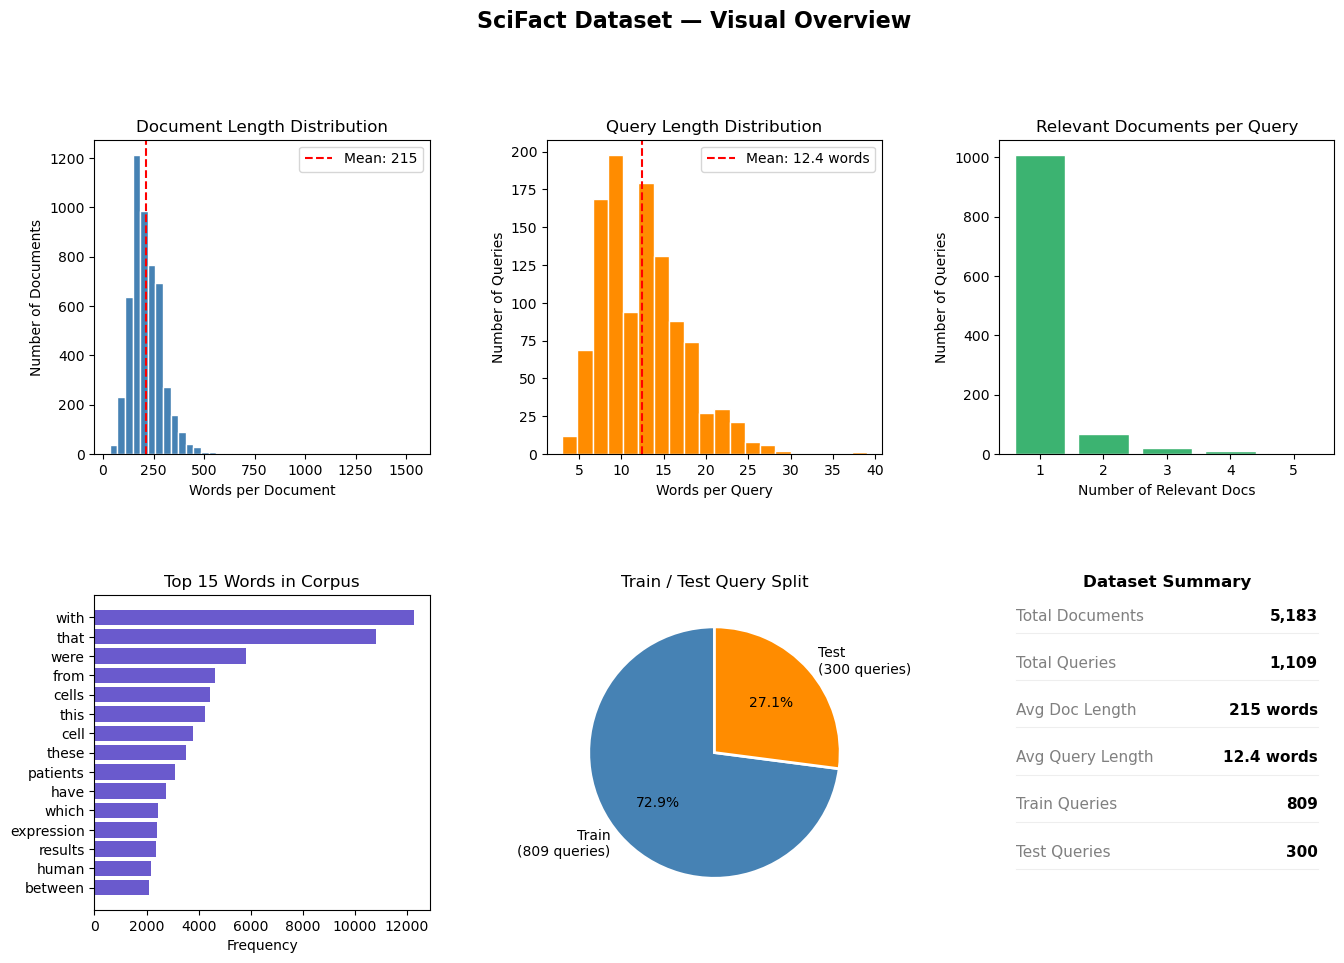

Dataset visualization complete.


In [3]:
from src.visualization import plot_dataset_overview

plot_dataset_overview(corpus, queries, qrels_train, qrels_test, qrels_all)

## Step 3: Preprocessing

In [4]:
tokenized_corpus, tokenized_queries = tokenize_dataset(corpus, queries)

sample_id = list(queries.keys())[0]
print("Original :", queries[sample_id])
print("Tokenised:", tokenized_queries[sample_id])

Original : 0-dimensional biomaterials lack inductive properties.
Tokenised: ['0dimensional', 'biomaterials', 'lack', 'inductive', 'properties']


## Step 3: Retrieval Systems

We define a shared `retrieve_documents()` helper that works with any dense or sparse matrix.

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def retrieve_documents(query_vectors, document_vectors, corpus_ids, top_k=10):
    """
    Rank corpus documents for each query by cosine similarity.

    Parameters
    ----------
    query_vectors     : array-like (n_queries, n_dims)
    document_vectors  : array-like (n_docs, n_dims)
    corpus_ids        : list of str  — document IDs in the same order as document_vectors
    top_k             : int

    Returns
    -------
    dict { query_index : [(doc_id, score), ...] }
    """
    similarity_matrix = cosine_similarity(query_vectors, document_vectors)
    results = {}
    for q_idx in range(len(similarity_matrix)):
        scores         = similarity_matrix[q_idx]
        ranked_indices = np.argsort(scores)[::-1]
        results[q_idx] = [(corpus_ids[idx], scores[idx]) for idx in ranked_indices[:top_k]]
    return results


def convert_rankings_to_query_ids(rankings, query_ids):
    """Replace integer query indices with their string query IDs."""    
    return {query_ids[q_idx]: docs for q_idx, docs in rankings.items()}

### 1. Normal VSM (TF-IDF + Cosine Similarity)

Sparse high-dimensional vectors. Each dimension = one vocabulary term. Similarity = angle between vectors.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus_ids     = list(tokenized_corpus.keys())
corpus_strings = [" ".join(tokens) for tokens in tokenized_corpus.values()]
query_ids      = list(tokenized_queries.keys())
query_strings  = [" ".join(tokens) for tokens in tokenized_queries.values()]

vectorizer = TfidfVectorizer()
X_corpus   = vectorizer.fit_transform(corpus_strings)
X_queries  = vectorizer.transform(query_strings)

print(f"Corpus matrix : {X_corpus.shape}")
print(f"Query matrix  : {X_queries.shape}")

Corpus matrix : (5183, 50625)
Query matrix  : (1109, 50625)


In [8]:
rankings_vsm = retrieve_documents(X_queries, X_corpus, corpus_ids)
rankings_vsm = convert_rankings_to_query_ids(rankings_vsm, query_ids)

# Verification
sample_id = query_ids[0]
print(f"Query: {queries[sample_id]}\n")
for doc_id, score in rankings_vsm[sample_id][:5]:
    label = '✅' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌'
    print(f"  {label}  {score:.4f}  {corpus[doc_id].get('title', '')[:70]}")

Query: 0-dimensional biomaterials lack inductive properties.

  ❌  0.0621  Geometry, epistasis, and developmental patterning.
  ❌  0.0600  In situ regulation of DC subsets and T cells mediates tumor regression
  ❌  0.0575  Lack of Absent in Melanoma 2 (AIM2) expression in tumor cells is close
  ❌  0.0560  Computational and Statistical Analyses of Amino Acid Usage and Physico
  ❌  0.0553  The effects of prion protein proteolysis and disaggregation on the str


### 2. VSM + LSI (Latent Semantic Indexing)

**Singular Value Decomposition (SVD)** reduces the TF-IDF matrix to 300 latent topic dimensions. The hope: documents about the same topic cluster together even if they use different words.

In [9]:
from sklearn.decomposition import TruncatedSVD

svd          = TruncatedSVD(n_components=300, random_state=42)
X_corpus_lsi = svd.fit_transform(X_corpus)
X_queries_lsi = svd.transform(X_queries)

print(f"LSI corpus shape : {X_corpus_lsi.shape}")
print(f"LSI query shape  : {X_queries_lsi.shape}")

LSI corpus shape : (5183, 300)
LSI query shape  : (1109, 300)


In [10]:
rankings_lsi = retrieve_documents(X_queries_lsi, X_corpus_lsi, corpus_ids)
rankings_lsi = convert_rankings_to_query_ids(rankings_lsi, query_ids)

# Verification
sample_id = query_ids[0]
print(f"Query: {queries[sample_id]}\n")
for doc_id, score in rankings_lsi[sample_id][:5]:
    label = '✅' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌'
    print(f"  {label}  {score:.4f}  {corpus[doc_id].get('title', '')[:70]}")

Query: 0-dimensional biomaterials lack inductive properties.

  ❌  0.3737  Metastatic colonization requires the repression of the epithelial-mese
  ❌  0.3499  The effects of prion protein proteolysis and disaggregation on the str
  ❌  0.3401  The Epithelial-Mesenchymal Transition Generates Cells with Properties 
  ❌  0.3107  Spatiotemporal regulation of epithelial-mesenchymal transition is esse
  ❌  0.2924  Biochemical Properties of Highly Neuroinvasive Prion Strains


### 3. VSM + Transformer Embeddings

`all-MiniLM-L6-v2` converts text into **384-dimensional dense vectors** that encode *semantic meaning*, not just word overlap. Two sentences about the same concept will be close in this space even if they share no words.

In [11]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [12]:
corpus_texts = [
    doc.get('title', '') + " " + doc.get('text', '')
    for doc in corpus.values()
]
query_texts = list(queries.values())

print("Encoding corpus documents...")
doc_embeddings = model.encode(corpus_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"Document embeddings shape: {doc_embeddings.shape}")

print("\nEncoding queries...")
query_embeddings = model.encode(query_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)
print(f"Query embeddings shape: {query_embeddings.shape}")

Encoding corpus documents...


Batches:   0%|          | 0/162 [00:00<?, ?it/s]

Document embeddings shape: (5183, 384)

Encoding queries...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

Query embeddings shape: (1109, 384)


In [13]:
rankings_embed = retrieve_documents(query_embeddings, doc_embeddings, corpus_ids)
rankings_embed = convert_rankings_to_query_ids(rankings_embed, query_ids)

# Verification
sample_id = query_ids[0]
print(f"Query: {queries[sample_id]}\n")
for doc_id, score in rankings_embed[sample_id][:5]:
    label = '✅' if qrels_all.get(sample_id, {}).get(doc_id, 0) > 0 else '❌'
    print(f"  {label}  {score:.4f}  {corpus[doc_id].get('title', '')[:70]}")

Query: 0-dimensional biomaterials lack inductive properties.

  ❌  0.3453  Complex Tissue and Disease Modeling using hiPSCs.
  ❌  0.3333  Nonlinear Elasticity in Biological Gels
  ❌  0.3129  Mechanical regulation of cell function with geometrically modulated el
  ✅  0.2879  New opportunities: the use of nanotechnologies to manipulate and track
  ❌  0.2871  Emergent structures and dynamics of cell colonies by contact inhibitio


## Step 4: Evaluation

All three models are evaluated head-to-head on Precision@10, Recall@10, and NDCG@10.

In [14]:
from src.evaluation import evaluate_rankings, print_results

vsm_p,   vsm_r,   vsm_n   = evaluate_rankings(rankings_vsm,   qrels_all, k=10)
lsi_p,   lsi_r,   lsi_n   = evaluate_rankings(rankings_lsi,   qrels_all, k=10)
embed_p, embed_r, embed_n  = evaluate_rankings(rankings_embed, qrels_all, k=10)

print_results({
    'Normal VSM (TF-IDF)':      (vsm_p,   vsm_r,   vsm_n),
    'VSM + LSI (SVD-300)':      (lsi_p,   lsi_r,   lsi_n),
    'VSM + Transformers (MiniLM)': (embed_p, embed_r, embed_n),
})

Model                               P@10        R@10     NDCG@10
----------------------------------------------------------------
Normal VSM (TF-IDF)               0.0814      0.7286      0.5746
VSM + LSI (SVD-300)               0.0610      0.5358      0.3944
VSM + Transformers (MiniLM)       0.0890      0.7850      0.6561


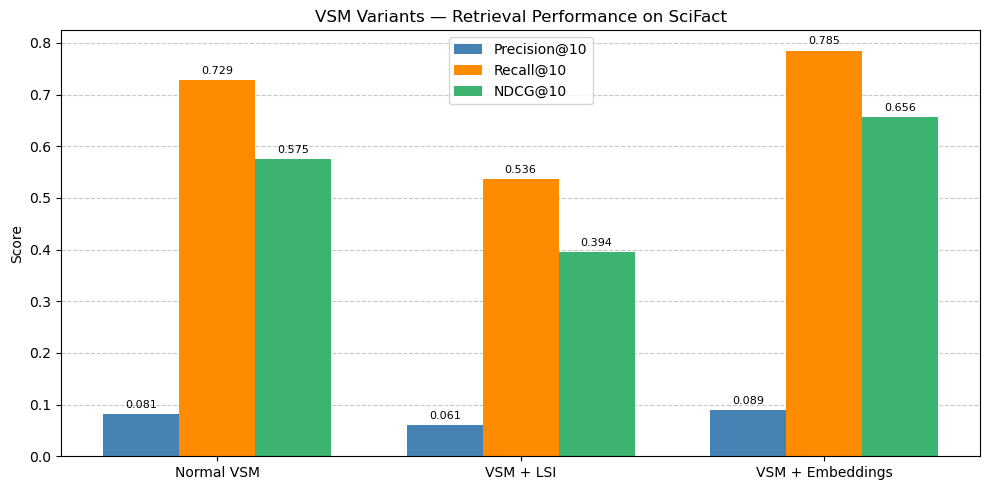

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models  = ['Normal VSM', 'VSM + LSI', 'VSM + Embeddings']
p_vals  = [vsm_p,   lsi_p,   embed_p]
r_vals  = [vsm_r,   lsi_r,   embed_r]
n_vals  = [vsm_n,   lsi_n,   embed_n]

x, width = np.arange(3), 0.25
fig, ax  = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - width, p_vals, width, label='Precision@10', color='steelblue')
b2 = ax.bar(x,         r_vals, width, label='Recall@10',    color='darkorange')
b3 = ax.bar(x + width, n_vals, width, label='NDCG@10',      color='mediumseagreen')

ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('Score'); ax.set_title('VSM Variants — Retrieval Performance on SciFact')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7); ax.set_axisbelow(True)
for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout(); plt.show()

### Conclusion

**Embeddings win — by a significant margin.**

| Model | Why |
|-------|-----|
| **Normal VSM** | Fast, interpretable, but blind to synonyms and paraphrasing |
| **VSM + LSI** | Tries to capture topics, but compressing to 300 dimensions discards precise scientific vocabulary — the exact terms that matter most |
| **VSM + Embeddings** | Encodes *meaning*, not just words. "Reduces mortality" and "lowers death rate" land near each other in embedding space |

**The takeaway:** TF-IDF sees words → LSI sees topics → Embeddings understand meaning.